In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
import joblib

In [28]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)
        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [29]:
# Loads features and target variables
def load_data(filename, y_target_name, num_rows = -1, pos = 0):
    df = pd.read_csv(filename)
    if num_rows  > 0:
        df = df[pos:pos + num_rows]
    elif pos != 0:
        df = df[pos:]
        
    X = df.drop(columns=[y_target_name])
    y = df[y_target_name]
    
    return X, y, df

In [30]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [df.columns[i] for i, item in enumerate(df.dtypes) if not pd.api.types.is_numeric_dtype(item)]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32,16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [31]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [45]:
def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    C_grid = np.logspace(-4, 4, 20)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print(f"working on {i} with C value: {C:.4f}")
        clf = LogisticRegression(C=C, l1_ratio=0, solver="lbfgs", max_iter=500).fit(X_train, y_train)
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        # print(f"{y_train_pred=}")
        # print(f"{y_test_pred=}")
        print(f"{y_train_log_loss=:.4f}")
        print(f"{y_test_log_loss=:.4f}")
        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(C_grid, y_train_log_loss_data, "o-", color="blue", label="Training Data Log-Loss", markersize=3)
    plt.plot(C_grid, y_test_log_loss_data, "o-", color="red", label="Test Data Log-Loss", markersize=3)
    
    plt.xlabel("C") 
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    # plt.ylim([0, 1])
    plt.xscale("log")
    plt.legend()
    plt.savefig("../outputs/logistic_regression_log_loss_c.png")
    
    clf = LogisticRegression(C=5, l1_ratio=0, solver="lbfgs", max_iter=500).fit(X_train, y_train)
    return clf

In [33]:
clean_csv("../data/uci_phishing_url_dataset.csv", "../data/uci_phishing_url_dataset_clean.csv", ["FILENAME", "URL", "Domain", "TLD", "Title", "HasTitle","DomainTitleMatchScore","URLTitleMatchScore","HasFavicon","Robots","IsResponsive","NoOfURLRedirect","NoOfSelfRedirect","HasDescription","NoOfPopup","NoOfiFrame","HasExternalFormSubmit","HasSocialNet","HasSubmitButton","HasHiddenFields","HasPasswordField","Bank","Pay","Crypto","HasCopyrightInfo","NoOfImage","NoOfCSS","NoOfJS","NoOfSelfRef","NoOfEmptyRef","NoOfExternalRef", "URLSimilarityIndex","CharContinuationRate","TLDLegitimateProb","URLCharProb", "LineOfCode", "LargestLineLength"])

file: "../data/uci_phishing_url_dataset.csv" cleaned successfully


True

remove "FILENAME" column from data


In [34]:
X, y, df = load_data("../data/uci_phishing_url_dataset_clean.csv", "IsLegit", 100000)


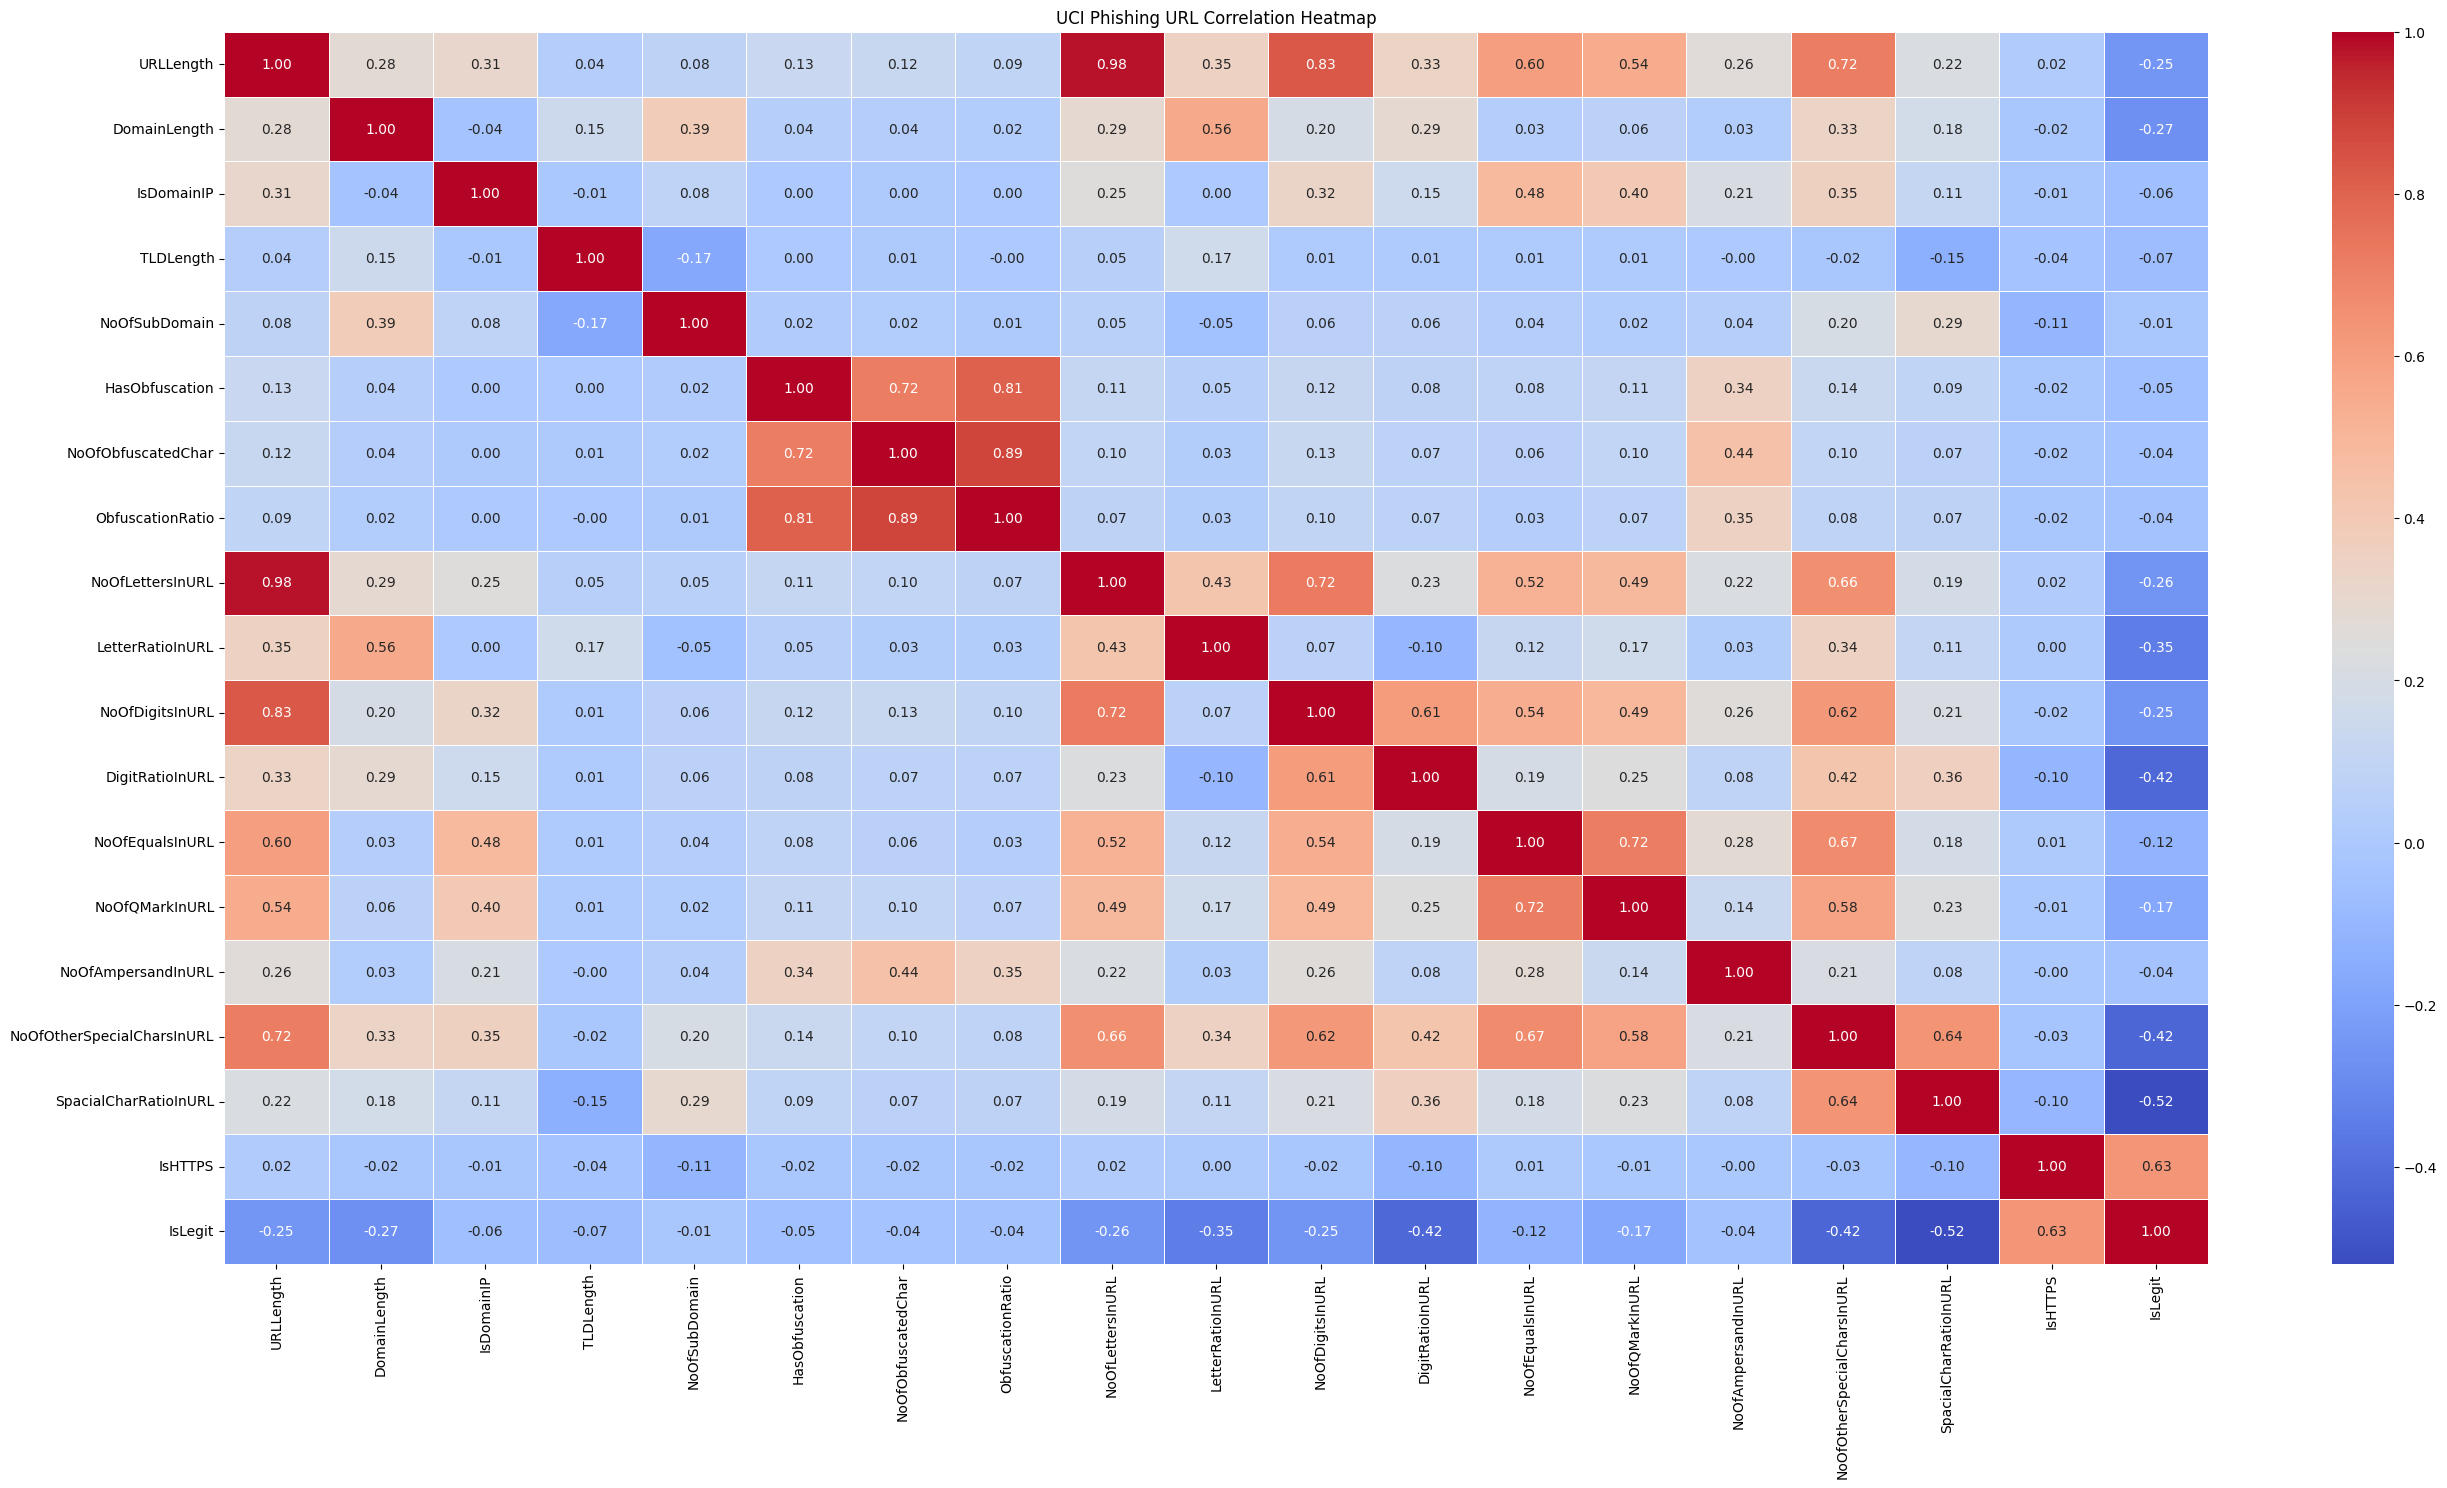

In [35]:
show_corr_matrix(df, "../outputs/uci_phishing_url_corr_matrix.png")

working on 0 with C value: 0.0001
y_train_log_loss=0.3169
y_test_log_loss=0.3194
working on 1 with C value: 0.0003
y_train_log_loss=0.2146
y_test_log_loss=0.2168
working on 2 with C value: 0.0007
y_train_log_loss=0.1293
y_test_log_loss=0.1314
working on 3 with C value: 0.0018
y_train_log_loss=0.0748
y_test_log_loss=0.0768
working on 4 with C value: 0.0048
y_train_log_loss=0.0451
y_test_log_loss=0.0471
working on 5 with C value: 0.0127
y_train_log_loss=0.0300
y_test_log_loss=0.0321
working on 6 with C value: 0.0336
y_train_log_loss=0.0221
y_test_log_loss=0.0241
working on 7 with C value: 0.0886
y_train_log_loss=0.0179
y_test_log_loss=0.0195
working on 8 with C value: 0.2336
y_train_log_loss=0.0154
y_test_log_loss=0.0163
working on 9 with C value: 0.6158
y_train_log_loss=0.0142
y_test_log_loss=0.0147
working on 10 with C value: 1.6238
y_train_log_loss=0.0136
y_test_log_loss=0.0140
working on 11 with C value: 4.2813
y_train_log_loss=0.0133
y_test_log_loss=0.0136
working on 12 with C value

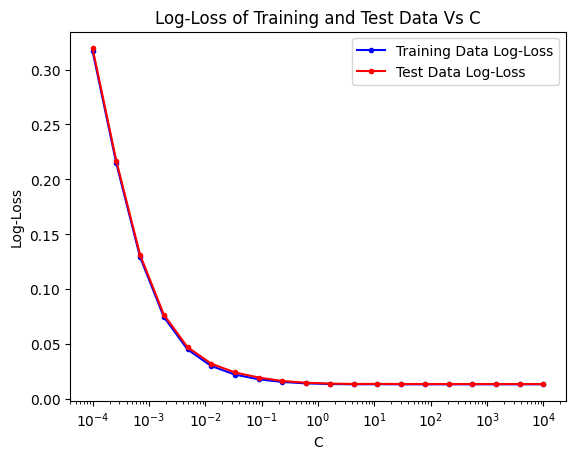

In [46]:

X_train, X_test, y_train, y_test =  get_training_test_data(X, y)
clf = logistic_regression_model_training(X_train, X_test, y_train, y_test)

In [49]:
joblib.dump(clf, "../models/logit_model.pkl") 

['../models/logit_model.pkl']

In [50]:
clf2 = joblib.load("../models/logit_model.pkl")
X_new, y_new, df_new = load_data("../data/uci_phishing_url_dataset_clean.csv", "IsLegit", pos=100000)
print(clf2.coef_)
y_new_pred = clf2.predict(X_new)

accuracy = accuracy_score(y_new, y_new_pred)
print(f"Accuracy: {accuracy}")

[[-3.55205978e+00  7.51404679e+00 -9.12280791e-03 -6.42191233e-01
  -4.13507334e-01 -2.79013974e-03 -1.56771221e-02 -1.95944279e-04
  -4.00464866e+00 -6.07461806e-01 -4.77602122e+00 -2.13310440e-01
  -4.17173278e-02 -4.18612377e-02 -6.48667891e-03 -4.97581233e+00
  -9.54867615e-02  1.72594386e+01]]
Accuracy: 0.997636142715122
